In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from prophet import Prophet


In [12]:
df = pd.read_csv("../data/raw/tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [13]:
print("Shape:", df.shape)

Shape: (2640, 12)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [16]:
df.isnull().sum().sort_values(ascending=False)  #It is used to find the number null values present in every columns

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [17]:
print("Duplicates:", df.duplicated().sum())


df = df.drop_duplicates()

Duplicates: 0


In [18]:
#We need to create datetime because we need it for forecasting
df["Date"] = pd.to_datetime(   
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1
    )
)

df.head()    

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


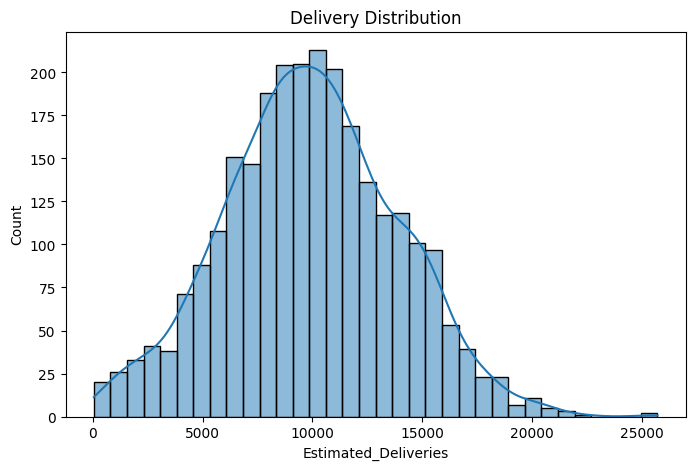

In [19]:
#Target Distribution

plt.figure(figsize=(8,5))
sns.histplot(
    df["Estimated_Deliveries"],
    kde=True
)

plt.title("Delivery Distribution")
plt.show()

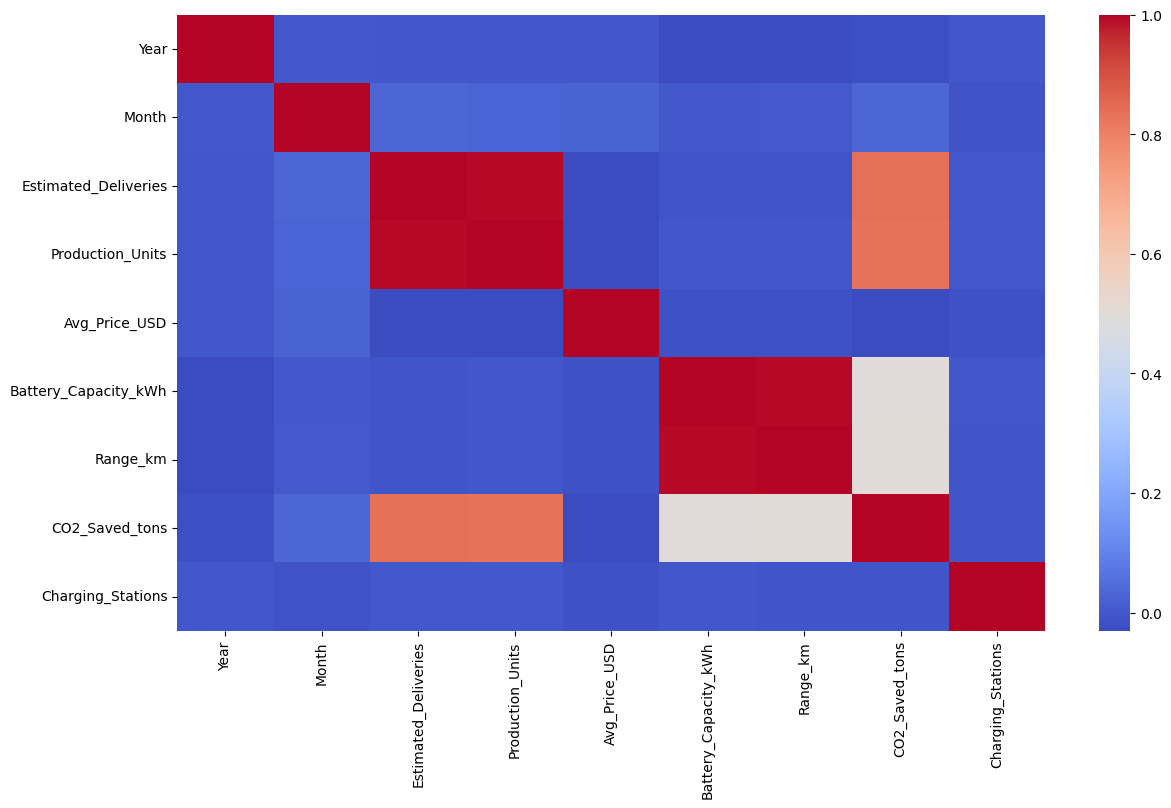

In [20]:
## Correlation Analysis --- it is used to identify important numerical drivers

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.show()


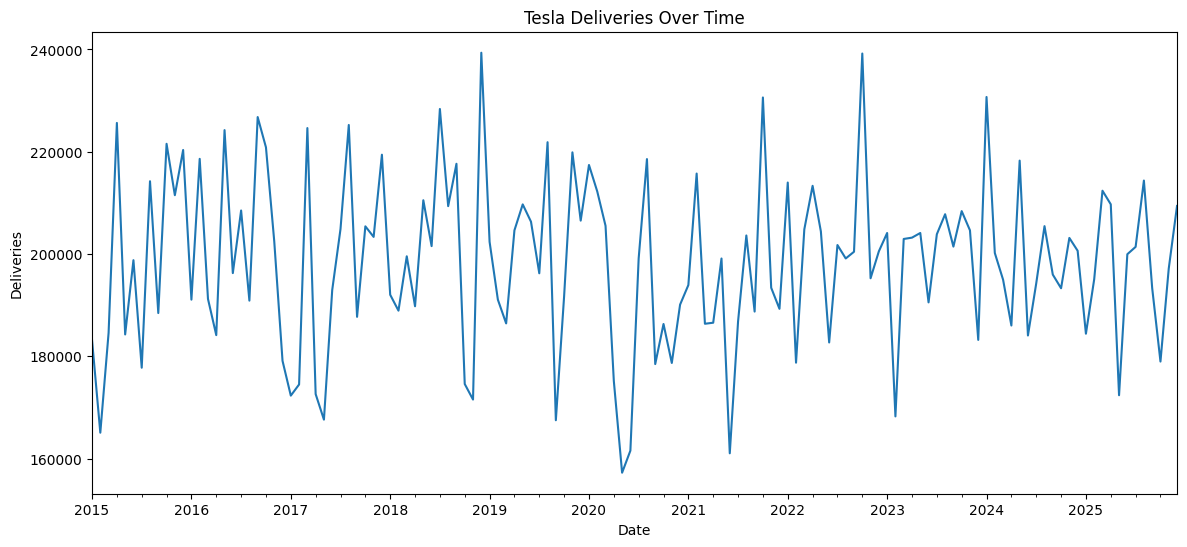

In [21]:
#Monthly Trend 

monthly = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

plt.figure(figsize=(14,6))
monthly.plot()
plt.title("Tesla Deliveries Over Time")
plt.ylabel("Deliveries")

plt.show()

### Feature Engineering

In [22]:
df["Price_per_kWh"] = (df["Avg_Price_USD"] / df["Battery_Capacity_kWh"])

df["Range_per_kWh"] = (df["Range_km"] / df["Battery_Capacity_kWh"])

# We perform Feature Engineering Because Raw features don't capture operational efficiency and Ratios often provide stronger predictive power


In [23]:
df["Month_Sin"] = np.sin(2*np.pi*df["Month"]/12)

df["Month_Cos"] = np.cos(2*np.pi*df["Month"]/12)

# We Often perform this because December and january are close in time .So, Integer encoding cannot represent this relationship

In [ ]:
## Defining Features

X = df.drop(columns=["Estimated_Deliveries", "Date", "Production_Units"])
y = df["Estimated_Deliveries"]


## I have dropeed Production_units from x to prevent data leakage , ensuring the model learns to forecast truw consumer market demand based on procing and features , rather than memorizing the output.


In [25]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns  

#We only consider the columns when ther data type are integer and float for input 

## Preprocessing Pipeline



In [26]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numerical_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

###  Train Test Split


In [27]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


 ### Model Pipeline

In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import time
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go
import plotly.express as px
from prophet import Prophet

# 1. Defining  all models we want to compare
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}


In [ ]:
results = []
best_r2 = -float('inf')
best_model_name = None
best_model_obj = None

for name, model in models.items():
    start_time = time.time()
    

    p = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    p.fit(X_train, y_train)
    y_pred = p.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model_obj = model
        
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})

metrics_df = pd.DataFrame(results)
print(metrics_df)
print(f"\n🏆 Automatically selected {best_model_name} as the best model with R2={best_r2:.4f}")


metrics_df.to_csv('../reports/model_metrics.csv', index=False)


#Creating pipeline for every model and training them .. and finding the best model based on R2_score and string the metric in the .csv file


               Model         MAE         RMSE  R2 Score
0      Random Forest  111.261553   199.279083  0.997411
1            XGBoost  134.548798   226.969083  0.996642
2           AdaBoost  927.384383  1111.372138  0.919488
3  Gradient Boosting  165.547189   226.946033  0.996643

🏆 Automatically selected Random Forest as the best model with R2=0.9974


##### Hyper Parameter Tuning

In [ ]:
# Create a pipeline for the best model
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_obj)
])


if best_model_name == 'Random Forest':
    param_grid = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [5, 10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }
elif best_model_name == 'XGBoost':
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }
else: # AdaBoost
    param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 1.0]
    }

print(f"Running RandomizedSearchCV for {best_model_name}...")
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20, cv=5, scoring="neg_mean_absolute_error", 
    random_state=42, n_jobs=-1
)

random_search.fit(X_train, y_train)


best_pipeline = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)


#After performing hyperparameter tuning .. best model that is random forest is tuned well 


Running RandomizedSearchCV for Random Forest...
Best Hyperparameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': None}


In [ ]:
# prediction using the tunned model
y_pred_tuned = best_pipeline.predict(X_test)

print(f"--- Tuned {best_model_name} Performance ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_tuned):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred_tuned):.4f}")


--- Tuned Random Forest Performance ---
MAE: 111.65
RMSE: 197.94
R² Score: 0.9974


#### Feature Importance

In [68]:
## Extracting model from its pipeline
tuned_model = best_pipeline.named_steps['model']

try:
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
except AttributeError:
    feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

if hasattr(tuned_model, 'feature_importances_'):
    importances = tuned_model.feature_importances_
    feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    feat_df = feat_df.sort_values(by="Importance", ascending=True).tail(15)
    
    fig_feat = px.bar(feat_df, x="Importance", y="Feature", orientation='h',
                 color="Importance", 
                 color_continuous_scale=["#94a3b8", "#e23636"],
                 title=f"Top 15 Feature Importances ({best_model_name})")
    
    fig_feat.update_layout(template="plotly_white")
    fig_feat.show()
else:
    print(f"{best_model_name} does not support standard feature_importances_ extraction.")


#### Actual vs Predicted values 

In [ ]:
import plotly.express as px

results_df = pd.DataFrame({
    'Actual Deliveries': y_test,
    'Predicted Deliveries': y_pred_tuned 
})


fig_pred = px.scatter(
    results_df, x='Actual Deliveries', y='Predicted Deliveries', 
    template='plotly_white', opacity=0.7,
    title=f"Model Evaluation: Actual vs Predicted Deliveries ({best_model_name})"
)


fig_pred.add_shape(
    type="line", line=dict(dash="dash", color="#e23636"),
    x0=results_df['Actual Deliveries'].min(), y0=results_df['Actual Deliveries'].min(),
    x1=results_df['Actual Deliveries'].max(), y1=results_df['Actual Deliveries'].max()
)

fig_pred.show()


In [ ]:

joblib.dump(best_pipeline, '../model/tesla_delivery_model.pkl')
print("Model successfully saved to '../model/tesla_delivery_model.pkl'")


Model successfully saved to '../model/tesla_delivery_model.pkl'


### Prophet Model 

In [64]:

trend_df = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
trend_df.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'}, inplace=True)


m = Prophet()
m.fit(trend_df)

## I have trained prophet model because it can easily finds future tesla deliveries based on historical time trends and seasonality


11:55:59 - cmdstanpy - INFO - Chain [1] start processing
11:56:00 - cmdstanpy - INFO - Chain [1] done processing


In [65]:

future = m.make_future_dataframe(periods=24, freq='MS')  ## forecasting 24 months into the future
forecast = m.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


            ds           yhat     yhat_lower     yhat_upper
151 2027-08-01  210878.754742  190812.531163  230558.374805
152 2027-09-01  188887.501057  169284.805600  208755.659283
153 2027-10-01  204839.488871  186016.096420  223669.079044
154 2027-11-01  199629.009044  179736.223460  218875.292366
155 2027-12-01  204514.656388  185516.505055  222708.837215


##### Forecasting

In [66]:

fig_forecast = go.Figure()

fig_forecast.add_trace(go.Scatter(
    x=trend_df['ds'], y=trend_df['y'], mode='lines', 
    name='Historical', line=dict(color='#475569')
))
fig_forecast.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_upper'], mode='lines', 
    line=dict(width=0), showlegend=False
))
fig_forecast.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat_lower'], mode='lines', 
    line=dict(width=0), fillcolor='rgba(226, 54, 54, 0.2)', fill='tonexty', showlegend=False
))

fig_forecast.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'], mode='lines', 
    name='Forecast', line=dict(color='#e23636', width=3)
))

fig_forecast.update_layout(
    template='plotly_white', 
    hovermode='x unified', margin=dict(l=0, r=0, t=30, b=0),
    title='Tesla Global Deliveries Forecast'
)

fig_forecast.show()


c:\Users\anvesh4\AppData\Local\Programs\Python\Python310\lib\site-packages\_plotly_utils\basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



#### Displying the future 24 months tesla deliveries 

In [ ]:

future_deliveries = forecast[['ds', 'yhat']].tail(24).copy()
future_deliveries.rename(columns={'ds': 'Future Date', 'yhat': 'Predicted Deliveries'}, inplace=True)
future_deliveries['Predicted Deliveries'] = future_deliveries['Predicted Deliveries'].round(0).astype(int)
print("📅 Predicted Tesla Deliveries for the Next 24 Months:")
print(future_deliveries.style.background_gradient(cmap='Blues'))


📅 Predicted Tesla Deliveries for the Next 24 Months:


,Future Date,Predicted Deliveries
132,2026-01-01 00:00:00,196487
133,2026-02-01 00:00:00,191974
134,2026-03-01 00:00:00,195309
135,2026-04-01 00:00:00,197741
136,2026-05-01 00:00:00,194863
137,2026-06-01 00:00:00,190388
138,2026-07-01 00:00:00,198695
139,2026-08-01 00:00:00,210150
140,2026-09-01 00:00:00,192711
141,2026-10-01 00:00:00,204428


### Conclusion

* Random Forest achieved the best performance with an R² score of 0.9974, making it the most effective model for delivery prediction.
* Battery Capacity, Vehicle Range, and Regional Availability were identified as the most influential factors affecting delivery volumes.
* The Prophet Time Series model successfully forecasted future deliveries by capturing historical trends and seasonality patterns.
* Forecast results indicate a steady growth in deliveries over the next 24 months, providing valuable insights for production planning and business decision-making.